In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [32]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("../data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


In [33]:
data.head()

,text,label
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1
1,Will do.,0
2,Nora--Cheryl has emailed dozens of memos about...,0
3,Dear Sir=2FMadam=2C I know that this proposal ...,1
4,fyi,0


### Let's divide the training and test set into two partitions

In [34]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data['text']   # Assuming 'text' is the email column 
y = data['label']  # Assuming 'label' is the label (0/1) -- Ham == 0  -- SPAM == 1

# Split the data: 80% for training and 20% for testing
# Dividir los datos: 80% para entrenamiento y 20% para pruebas
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42,   
)

# Print the results
# Imprimir los resultados
print(f"Training set size: {X_train.shape[0]}") # Tamaño del conjunto de entrenamiento
print(f"Test set size: {X_test.shape[0]}")         # Tamaño del conjunto de prueba


Training set size: 800
Test set size: 200


## Data Preprocessing

In [35]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [36]:
# 1 - First we remove inline JavaScript/CSS
import re

def javascript_css_remove_code(text):
    
    ## Remove script and style blocks using regular expressions.
    ## Eliminar bloques de script y style usando expresiones regulares.
    
    # Remove Java script tags and everything inside them
    text = re.sub(r'<script.*?>.*?</script>', '', text, flags=re.DOTALL | re.IGNORECASE)
    
    # Remove CSS - style tags and everything inside them
    text = re.sub(r'<style.*?>.*?</style>', '', text, flags=re.DOTALL | re.IGNORECASE)
    
    return text



In [37]:
# Apply remove JavaScript/CSS
X_train_cleaned = X_train.apply(javascript_css_remove_code)

X_test_cleaned = X_test.apply(javascript_css_remove_code)

# Check result
print(X_train_cleaned.iloc[2][:100])
X_train_cleaned.head()

; Huma Abedin B6I'm checking with Pat on the 50k will work with Jack & Jake on rest.Also Huma has fo


29     ----------- REGARDS, MR NELSON SMITH.KINDLY RE...
535    I have not been able to reach oscar this am. W...
695    ; Huma Abedin B6I'm checking with Pat on the 5...
557    I can have it announced here on Monday - can't...
836        BANK OF AFRICAAGENCE SAN PEDRO14 BP 1210 S...
Name: text, dtype: object

In [38]:
# 2 - Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
import re

def html_comments_remove_code(text):
    # Remove HTML comments 
    
    # # Define the pattern to find: html comments - r'' -
    comment_pattern = re.compile(r'', flags=re.DOTALL)
    
    # regex Replace 
    cleaned_text = re.sub(comment_pattern, '', text)
    
    return cleaned_text


In [39]:
# Apply html_comments_remove

X_train_no_html_comments = X_train_cleaned.apply(html_comments_remove_code)
X_test_no_html_comments = X_test_cleaned.apply(html_comments_remove_code)
# Check result
print(X_train_no_html_comments.iloc[1][:100])

X_train_no_html_comments.head()

I have not been able to reach oscar this am. We are supposed to send the pdb at 11. Can u receive it


29     ----------- REGARDS, MR NELSON SMITH.KINDLY RE...
535    I have not been able to reach oscar this am. W...
695    ; Huma Abedin B6I'm checking with Pat on the 5...
557    I can have it announced here on Monday - can't...
836        BANK OF AFRICAAGENCE SAN PEDRO14 BP 1210 S...
Name: text, dtype: object

In [40]:
## Next we can remove the remaining tags
def tags_remove_code(text):
    
    ## Remove tags
    text = re.sub(r'<.*?>', '', text, flags=re.DOTALL | re.IGNORECASE)
       
    return text

In [41]:
# Apply tags_remove_code

X_train_no_tags = X_train_no_html_comments.apply(tags_remove_code)
X_test_no_tags = X_test_no_html_comments.apply(tags_remove_code)
# Check result
print(X_train_no_tags.iloc[1][:100])

X_train_no_tags.head()

I have not been able to reach oscar this am. We are supposed to send the pdb at 11. Can u receive it


29     ----------- REGARDS, MR NELSON SMITH.KINDLY RE...
535    I have not been able to reach oscar this am. W...
695    ; Huma Abedin B6I'm checking with Pat on the 5...
557    I can have it announced here on Monday - can't...
836        BANK OF AFRICAAGENCE SAN PEDRO14 BP 1210 S...
Name: text, dtype: object

- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [44]:
# Your code
import re

def clean_text_complete(text):
    """
    -- Remove all the special characters
    -- Remove numbers
    -- Remove all single characters
    -- Remove single characters from the start
    -- Substitute multiple spaces with single space
    -- Remove prefixed 'b'
    -- Convert to Lowercase
    """
    
    # Convert to Lowercase
    
    text = text.lower()
    
    #  Remove all the special characters 
    ## text = re.sub(r'\W', ' ', text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Remove numbers
    text = re.sub(r'\d', ' ', text)
    
    # Remove all single characters --- Talking with Ana
    text = re.sub(r'\s+[a-z]\s+', ' ', text)
    
    # Remove single characters from the start --  Talking with Ana
    text = re.sub(r'^[a-z]\s+', ' ', text)
    
    # Substitute multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
        
    # Remove prefixed 'b' 
    text = re.sub(r'^b\s+', '', text)
    
    # Trim whitespaces from start and end
    text = text.strip()
       
    
    return text



In [45]:
# Apply 
X_train_clean_all = X_train_no_tags.apply(clean_text_complete)
X_test_clean_all = X_test_no_tags.apply(clean_text_complete)

# Preview the final result
# Previsualizar el resultado final
print(X_train_clean_all.iloc[0][:500])

X_train_clean_all.head()

regards mr nelson smith kindly reply me on my private email address nelsonsmith yahoo com


29     regards mr nelson smith kindly reply me on my ...
535    have not been able to reach oscar this am we a...
695    huma abedin i checking with pat on the will wo...
557       can have it announced here on monday can today
836    bank of africaagence san pedro bp san pedro co...
Name: text, dtype: object

## Now let's work on removing stopwords
Remove the stopwords.

In [47]:
# Your code
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

def remove_stopwords_only(text, language):
    
    ## Remove
    ## Tokenize
    tokenized_text = [word_tokenize(doc) for doc in text]
    # 1. Load the set of stopwords for the specific language
    # 1. Cargar el conjunto de stopwords para el idioma específico
    stop_words = set(stopwords.words(language.lower()))
    
    processed_docs = []
    
    # 2. Iterate through each document     
    for doc in tokenized_text:
        # Filter words that are not in the stopword list
        filtered_doc = [word for word in doc if word.lower() not in stop_words]
        processed_docs.append(filtered_doc)
      
    return processed_docs






[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\menot\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\menot\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [53]:
X_train_no_stopwords = remove_stopwords_only(X_train_clean_all, 'english')
X_test_no_stopwords = remove_stopwords_only(X_test_clean_all, 'english')



## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [54]:
# Your code
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Recursos necesarios para que el lematizador sea inteligente
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(word):
    """Mapea etiquetas POS al formato que WordNet entiende."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    
    return tag_dict.get(tag, wordnet.NOUN)


def lemmatize_and_join(tokenized_docs):
    """
    Recibe los tokens, los reduce a su raíz y los une en un string final.
    """
    lemmatizer = WordNetLemmatizer()
    final_processed_text = []
    
    for doc_tokens in tokenized_docs:
        # Lematizamos cada palabra usando su etiqueta POS
        lemmas = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in doc_tokens]
        
        # IMPORTANTE: Unimos de nuevo en un string para que el modelo lo entienda
        final_processed_text.append(" ".join(lemmas))
        
    return final_processed_text



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\menot\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\menot\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\menot\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [55]:
# Aplicamos la lematización sobre los resultados sin stopwords
X_train_final = lemmatize_and_join(X_train_no_stopwords)
X_test_final = lemmatize_and_join(X_test_no_stopwords)

# test
print("Final text for the model:")
print(X_train_final[0])


Final text for the model:
regard mr nelson smith kindly reply private email address nelsonsmith yahoo com


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# 1. Create a temporary DataFrame with the processed text and labels
# Note: Ensure y_train is aligned with X_train_final
df_bofw = pd.DataFrame({
    'text': X_train_final,
    'label': y_train  # Assuming y_train contains 'ham'/'spam' or 0/1
})

# 2. Separate ham and spam
ham_messages = df_bofw[df_bofw['label'] == 0]['text'] # Change 0 to 'ham' if needed
spam_messages = df_bofw[df_bofw['label'] == 1]['text'] # Change 1 to 'spam' if needed

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def get_top_n_words(corpus, n=10):
    """
    Extract the top N words from a list of documents.
    Extraer las N palabras principales de una lista de documentos.
    """
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    # Sum the counts of each word
    # Sumar los conteos de cada palabra
    sum_words = bag_of_words.sum(axis=0) 
    
    # Create a list of (word, frequency) pairs
    # Crear una lista de pares (palabra, frecuencia)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:n]




In [60]:
# Execute for both categories
# Ejecutar para ambas categorías
top_ham = get_top_n_words(ham_messages, 10)
top_spam = get_top_n_words(spam_messages, 10)

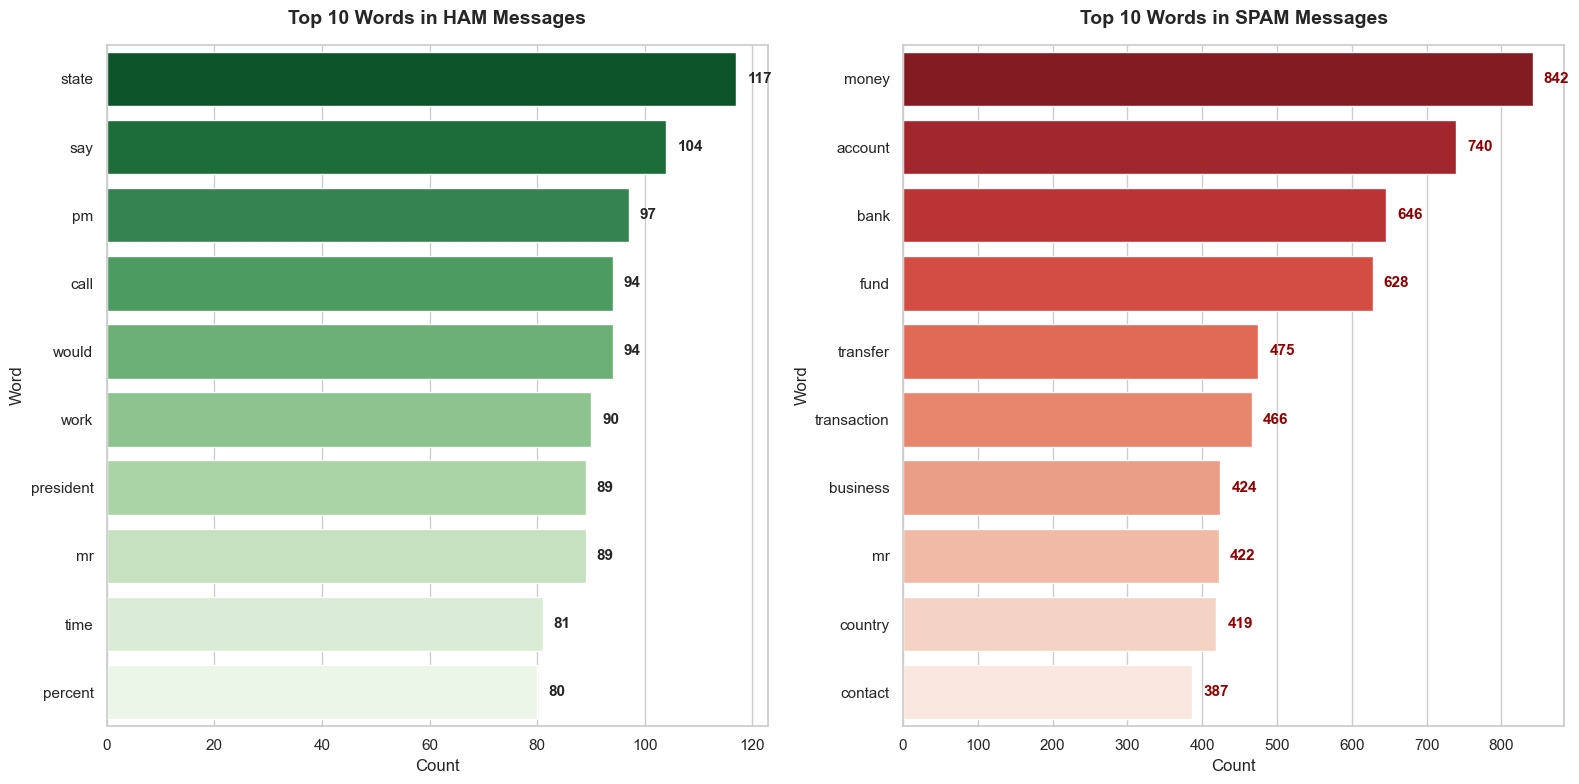

In [66]:
## plot

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- GRÁFICO 1: HAM ---
sns.barplot(x='Count', y='Word', data=df_ham, palette='Greens_r', hue='Word', legend=False, ax=ax1)
ax1.set_title('Top 10 Words in HAM Messages', fontsize=14, fontweight='bold', pad=15)

# Loop to put labels on EVERY HAM bar
for container in ax1.containers:
    ax1.bar_label(container, padding=8, fontsize=11, fontweight='bold')

# --- GRÁFICO 2: SPAM ---
sns.barplot(x='Count', y='Word', data=df_spam, palette='Reds_r', hue='Word', legend=False, ax=ax2)
ax2.set_title('Top 10 Words in SPAM Messages', fontsize=14, fontweight='bold', pad=15)

# Loop to put labels on EVERY SPAM bar
for container in ax2.containers:
    ax2.bar_label(container, padding=8, fontsize=11, fontweight='bold', color='darkred')

# 2. Ajustes finales
plt.tight_layout()
plt.show()

## Extra features

In [68]:
import pandas as pd

# 1. Creamos los DataFrames uniendo el texto lematizado con sus etiquetas
# Reconstruimos usando los resultados finales del paso anterior (X_train_final)
data_train = pd.DataFrame({
    'preprocessed_text': X_train_final, 
    'label': y_train.values
})

data_val = pd.DataFrame({
    'preprocessed_text': X_test_final, 
    'label': y_test.values
})

# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x)) 

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x)) 

data_train.head()

,preprocessed_text,label,money_mark,suspicious_words,text_len
0,regard mr nelson smith kindly reply private em...,1,0,0,79
1,able reach oscar suppose send pdb receive,0,0,0,41
2,huma abedin check pat work jack jake rest also...,0,0,0,73
3,announce monday today,0,0,0,21
4,bank africaagence san pedro bp san pedro cote ...,1,1,1,1023


## How would work the Bag of Words with Count Vectorizer concept?

In [70]:
# Your code
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize the CountVectorizer
# We can limit the number of features if the vocabulary is too large
vectorizer = CountVectorizer()

# 2. Fit and Transform the training data
# 'Fit' learns the vocabulary; 'Transform' creates the word count matrix
X_train_bow = vectorizer.fit_transform(data_train['preprocessed_text'])

# 3. Transform the validation data
# We ONLY use 'transform' to ensure we use the same vocabulary as the training set
X_val_bow = vectorizer.transform(data_val['preprocessed_text'])

# 4. Convert to array to see the shape
# The result is a Sparse Matrix (most values are 0)
print(f"Training Bag of Words shape: {X_train_bow.shape}")
print(f"Validation Bag of Words shape: {X_val_bow.shape}")

# 5. Check the vocabulary size
# Total number of unique words learned by the model
vocab_size = len(vectorizer.get_feature_names_out())
print(f"Total vocabulary size: {vocab_size}")

Training Bag of Words shape: (800, 27306)
Validation Bag of Words shape: (200, 27306)
Total vocabulary size: 27306


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [71]:
# Your code
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load the vectorizer
# We initialize the TfidfVectorizer. 
# We can use max_features to keep only the most important words.
tfidf_vectorizer = TfidfVectorizer()

# 2. Vectorize the dataset
# Fit and transform the training data to learn the vocabulary and inverse frequency
X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])

# Transform the validation data using the training vocabulary
X_val_tfidf = tfidf_vectorizer.transform(data_val['preprocessed_text'])

# 3. Print the shape of the vectorized dataset
# This shows (number of emails, number of features/words)
print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Validation TF-IDF shape: {X_val_tfidf.shape}")

# Optional: Check a small sample of the feature names
# print(tfidf_vectorizer.get_feature_names_out()[:20])

Training TF-IDF shape: (800, 27306)
Validation TF-IDF shape: (200, 27306)


## And the Train a Classifier?

In [72]:
# Your code
from scipy.sparse import hstack
import pandas as pd

# 1. Select the additional manual features
# Seleccionar las características manuales adicionales
extra_features_train = data_train[['money_mark', 'suspicious_words', 'text_len']].values
extra_features_val = data_val[['money_mark', 'suspicious_words', 'text_len']].values

# 2. Combine TF-IDF features with the manual features
# Combinar las características de TF-IDF con las manuales
X_train_final = hstack((X_train_tfidf, extra_features_train))
X_val_final = hstack((X_val_tfidf, extra_features_val))

print(f"Final training matrix shape: {X_train_final.shape}")


Final training matrix shape: (800, 27309)


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Classifier
# We use random_state for reproducibility
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
# Entrenar el modelo con los datos finales y las etiquetas
rf_classifier.fit(X_train_final, data_train['label'])

# 3. Make predictions on the validation set
# Realizar predicciones en el set de validación
y_pred = rf_classifier.predict(X_val_final)

# 4. Print the Performance Results
# Imprimir los resultados de rendimiento
print("--- Classification Report ---")
print(classification_report(data_val['label'], y_pred))

print(f"Overall Accuracy: {accuracy_score(data_val['label'], y_pred):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       125
           1       0.97      0.89      0.93        75

    accuracy                           0.95       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.95      0.95       200

Overall Accuracy: 0.9500


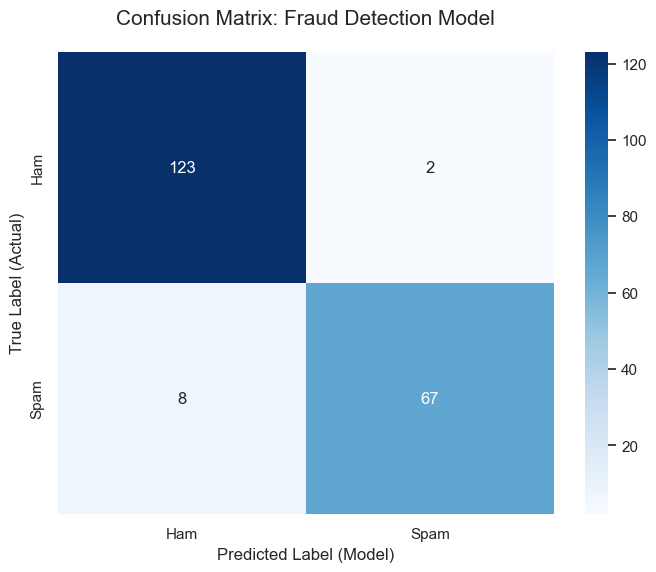

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix
# Generar la matriz de confusión comparando etiquetas reales vs predicciones
cm = confusion_matrix(data_val['label'], y_pred)

# 2. Create the labels for the matrix
# Crear las etiquetas para la matriz (0 = Ham, 1 = Spam)
labels = ['Ham', 'Spam']

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

# 4. Add titles and labels for clarity
# Añadir títulos y etiquetas para mayor claridad
plt.title('Confusion Matrix: Fraud Detection Model', fontsize=15, pad=20)
plt.xlabel('Predicted Label (Model)', fontsize=12)
plt.ylabel('True Label (Actual)', fontsize=12)

plt.show()

### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [75]:
from scipy.sparse import hstack

# Select manual features as arrays
# Seleccionar las características manuales como arreglos
extra_train = data_train[['money_mark', 'suspicious_words', 'text_len']].values
extra_val = data_val[['money_mark', 'suspicious_words', 'text_len']].values

In [76]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def test_mnb_scenario(X_train, X_val, y_train, y_val, name):
    # Train and evaluate a MultinomialNB model for a specific feature scenario.
    
    model = MultinomialNB() # Default parameters / Parámetros por defecto
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    
    print(f"Scenario: {name}")
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")
    print("-" * 30)
    return f1

# --- SCENARIO 1: Bag of Words only ---
vectorizer_bow = CountVectorizer()
X_train_1 = vectorizer_bow.fit_transform(data_train['preprocessed_text'])
X_val_1 = vectorizer_bow.transform(data_val['preprocessed_text'])
test_mnb_scenario(X_train_1, X_val_1, data_train['label'], data_val['label'], "BoW Only")

# --- SCENARIO 2: TF-IDF only ---
vectorizer_tfidf = TfidfVectorizer()
X_train_2 = vectorizer_tfidf.fit_transform(data_train['preprocessed_text'])
X_val_2 = vectorizer_tfidf.transform(data_val['preprocessed_text'])
test_mnb_scenario(X_train_2, X_val_2, data_train['label'], data_val['label'], "TF-IDF Only")

# --- SCENARIO 3: BoW + Extra Flags ---
X_train_3 = hstack((X_train_1, extra_train))
X_val_3 = hstack((X_val_1, extra_val))
test_mnb_scenario(X_train_3, X_val_3, data_train['label'], data_val['label'], "BoW + Flags")

# --- SCENARIO 4: TF-IDF + Extra Flags ---
X_train_4 = hstack((X_train_2, extra_train))
X_val_4 = hstack((X_val_2, extra_val))
test_mnb_scenario(X_train_4, X_val_4, data_train['label'], data_val['label'], "TF-IDF + Flags")

Scenario: BoW Only
Accuracy: 0.9500 | F1-Score: 0.9375
------------------------------
Scenario: TF-IDF Only
Accuracy: 0.9150 | F1-Score: 0.8982
------------------------------
Scenario: BoW + Flags
Accuracy: 0.8000 | F1-Score: 0.7872
------------------------------
Scenario: TF-IDF + Flags
Accuracy: 0.5450 | F1-Score: 0.6192
------------------------------


0.6192468619246861